# LAB090226 & LAB290226 — análisis *offline* del filtro de CO$_2$ (cascada del filtrado online)

**Objetivo:** aplicar a los datos históricos de CO$_2$ de las dos pruebas de fermentación exactamente la misma
cascada causal usada por el sistema online:

$$\text{CO}_2\ \text{raw} \;\to\; \text{Hampel causal} \;\to\; \text{Butterworth IIR causal (SOS)}$$

**Parámetros** (tomados de la documentación/implementación del filtro online
`fermentation_model/data/Multiplicador 2026/NEW_GUI_filtrado_vCTORREALBA_EZO_USB.py`):

| Etapa | Parámetro | Valor |
|---|---|---|
| Hampel | ventana temporal $W_H$ | 120 s |
| Hampel | umbral robusto $k$ | 3.5 |
| Hampel | umbral absoluto mínimo $\Delta_{\min}$ | 0.5 SCCM |
| Butterworth | constante de tiempo $\tau$ | 1200 s |
| Butterworth | orden $N$ | 3 |
| Butterworth | $f_c$ | $1/(2\pi\tau)$ |

**Convenciones de esta réplica offline**

- El periodo de muestreo real $T_s$ se estima **por archivo** como la mediana de los incrementos de timestamp
  (no se asume $T_s = 10$ s).
- Ventana del Hampel: $W = \mathrm{round}(W_H / T_s)$.
- Los coeficientes de Butterworth se recalculan con el $T_s$ real de cada archivo
  ($f_s = 1/T_s$, $\omega_n = f_c/(f_s/2)$).
- El Butterworth se implementa como IIR causal mediante secciones de segundo orden (`sosfilt`), **sin** `filtfilt`
  ni ningún filtro zero-phase; el estado interno se inicializa con `sosfilt_zi` escalado por la primera muestra,
  igual que en la implementación online, para evitar un transitorio artificial al inicio.
- El Hampel es causal: usa solo la muestra actual y las anteriores; $\sigma_{robusta} = 1.4826\,\mathrm{MAD}$;
  $\mathrm{threshold} = \max(k\,\sigma_{robusta}, \Delta_{\min})$; solo se reemplazan los spikes por la mediana local.

**Alcance:** no se optimizan ni modifican parámetros; no se exportan CSV filtrados; todo queda en este notebook.

In [1]:
from pathlib import Path
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

ROOT = Path.cwd()
while ROOT.name != "pyomo-doe" and ROOT.parent != ROOT:
    ROOT = ROOT.parent
if ROOT.name != "pyomo-doe":
    raise RuntimeError("Ejecutar este notebook desde el repositorio pyomo-doe")

DATA_DIR = ROOT / "fermentation_model" / "data" / "mem2026"
EXPERIMENTS = {
    "LAB090226": {
        "CO2":  {f"F{i}": DATA_DIR / "LAB090226" / f"CO2_F{i}.csv" for i in (1, 2, 3)},
        "Temp": {f"F{i}": DATA_DIR / "LAB090226" / f"Temp_F{i}.csv" for i in (1, 2, 3)},
    },
    "LAB290226": {
        "CO2":  {f"F{i}": DATA_DIR / "LAB290226" / f"F{i}_co2.csv" for i in (1, 2, 3)},
        "Temp": {f"F{i}": DATA_DIR / "LAB290226" / f"Temp_F{i}.csv" for i in (1, 2, 3)},
    },
}
for spec in EXPERIMENTS.values():
    for path in list(spec["CO2"].values()) + list(spec["Temp"].values()):
        assert path.exists(), f"No existe {path}"

# ---- Parametros del filtro online (replica exacta; NO optimizar ni modificar) ----
W_SPIKE_SECONDS = 120.0   # WH [s]
K_SPIKE = 3.5             # k
MIN_ABS_SPIKE = 0.5       # delta_min [SCCM]
TAU_SECONDS = 1200.0      # tau [s]
BUTTER_ORDER = 3          # N

COLORS = {"F1": "tab:blue", "F2": "tab:orange", "F3": "tab:green"}
plt.rcParams.setdefault("figure.dpi", 110)
plt.rcParams.setdefault("axes.grid", True)
plt.rcParams.setdefault("grid.alpha", 0.3)
print("ROOT =", ROOT)
# ---- Conversion oficial SCCM -> g L^-1 h^-1 (replica exacta de flow_sccm_to_co2_g_l_h_plot de NEW_GUI_filtrado_vFINAL.py) ----
# NO usar flow_to_rate_g_l_h() basada en CO2_DENSITY_G_M3 = 1964.0; la oficial para este notebook es la de la GUI actual.
STANDARD_MOLAR_VOLUME_L_PER_MOL = 24.16
CO2_MOLAR_MASS_G_PER_MOL = 44.0095
REACTOR_WORKING_VOLUME_L = 2.0
CO2_FLOW_CORRECTION_FACTOR = 0.74

def flow_sccm_to_co2_g_l_h_plot(flow_sccm: float) -> float:
    if STANDARD_MOLAR_VOLUME_L_PER_MOL <= 0 or REACTOR_WORKING_VOLUME_L <= 0:
        return 0.0
    # SCCM = cm3/min = mL/min; pasamos a L/min y luego a g/(L*h) de CO2 corregido.
    mol_per_min = (float(flow_sccm) / 1000.0) / STANDARD_MOLAR_VOLUME_L_PER_MOL
    g_per_h = mol_per_min * CO2_MOLAR_MASS_G_PER_MOL * 60.0 * CO2_FLOW_CORRECTION_FACTOR
    return g_per_h / REACTOR_WORKING_VOLUME_L


def sccm_to_g_L_h(arr) -> "np.ndarray":
    """Version vectorizada de flow_sccm_to_co2_g_l_h_plot (misma formula)."""
    arr = np.asarray(arr, dtype=float)
    return (arr * CO2_MOLAR_MASS_G_PER_MOL * 60.0 * CO2_FLOW_CORRECTION_FACTOR
            / (1000.0 * STANDARD_MOLAR_VOLUME_L_PER_MOL * REACTOR_WORKING_VOLUME_L))


ROOT = D:\claud\Desktop\Universidad\Memoria\Model\pyomo-doe


## 1. Carga de datos

Formatos (misma familia de archivos que el resto del repositorio):

- **CO$_2$**: `timestamp, fermentador, flow_sccm, status`
- **Temperatura**: `timestamp, fermentador, T, SP, banda, cold, hot, nutricion_activa, freq_nut`

In [2]:
def load_co2(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, dtype={"flow_sccm": str})
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df["flow_sccm"] = pd.to_numeric(df["flow_sccm"], errors="raise")
    df["status"] = df["status"].astype(str).str.strip()
    return df.sort_values("timestamp").reset_index(drop=True)


def load_temp(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df["T"] = pd.to_numeric(df["T"], errors="raise")
    return df.sort_values("timestamp").reset_index(drop=True)


def median_dt_seconds(ts: pd.Series) -> float:
    return float(np.median(np.diff(ts.values).astype("timedelta64[ns]").astype(float) / 1e9))


DATA = {}
for exp, spec in EXPERIMENTS.items():
    DATA[exp] = {
        ferm: {"co2": load_co2(spec["CO2"][ferm]), "temp": load_temp(spec["Temp"][ferm])}
        for ferm in ("F1", "F2", "F3")
    }

rows = []
for exp, ferms in DATA.items():
    for ferm, d in ferms.items():
        c, t = d["co2"], d["temp"]
        rows.append({
            "experimento": exp,
            "fermentador": ferm,
            "n_CO2": len(c),
            "Ts_CO2_med_s": round(median_dt_seconds(c["timestamp"]), 3),
            "n_Temp": len(t),
            "Ts_Temp_med_s": round(median_dt_seconds(t["timestamp"]), 3),
            "dur_h": round((c["timestamp"].iloc[-1] - c["timestamp"].iloc[0]).total_seconds() / 3600.0, 2),
            "inicio": str(c["timestamp"].iloc[0]),
            "fin": str(c["timestamp"].iloc[-1]),
        })
pd.DataFrame(rows)

,experimento,fermentador,n_CO2,Ts_CO2_med_s,n_Temp,Ts_Temp_med_s,dur_h,inicio,fin
0,LAB090226,F1,32357,10.0,96814,3.0,92.96,2026-02-05 13:11:34,2026-02-09 10:09:20
1,LAB090226,F2,32358,10.0,96814,3.0,92.96,2026-02-05 13:11:34,2026-02-09 10:09:20
2,LAB090226,F3,32358,10.0,96814,3.0,92.96,2026-02-05 13:11:44,2026-02-09 10:09:20
3,LAB290226,F1,29833,10.0,87553,3.0,88.95,2026-01-29 15:43:24,2026-02-02 08:40:22
4,LAB290226,F2,31221,10.0,87551,3.0,89.24,2026-01-29 15:43:46,2026-02-02 08:57:55
5,LAB290226,F3,31224,10.0,87551,3.0,89.25,2026-01-29 15:44:07,2026-02-02 08:59:08


## 2. Señales originales (sin filtrar)

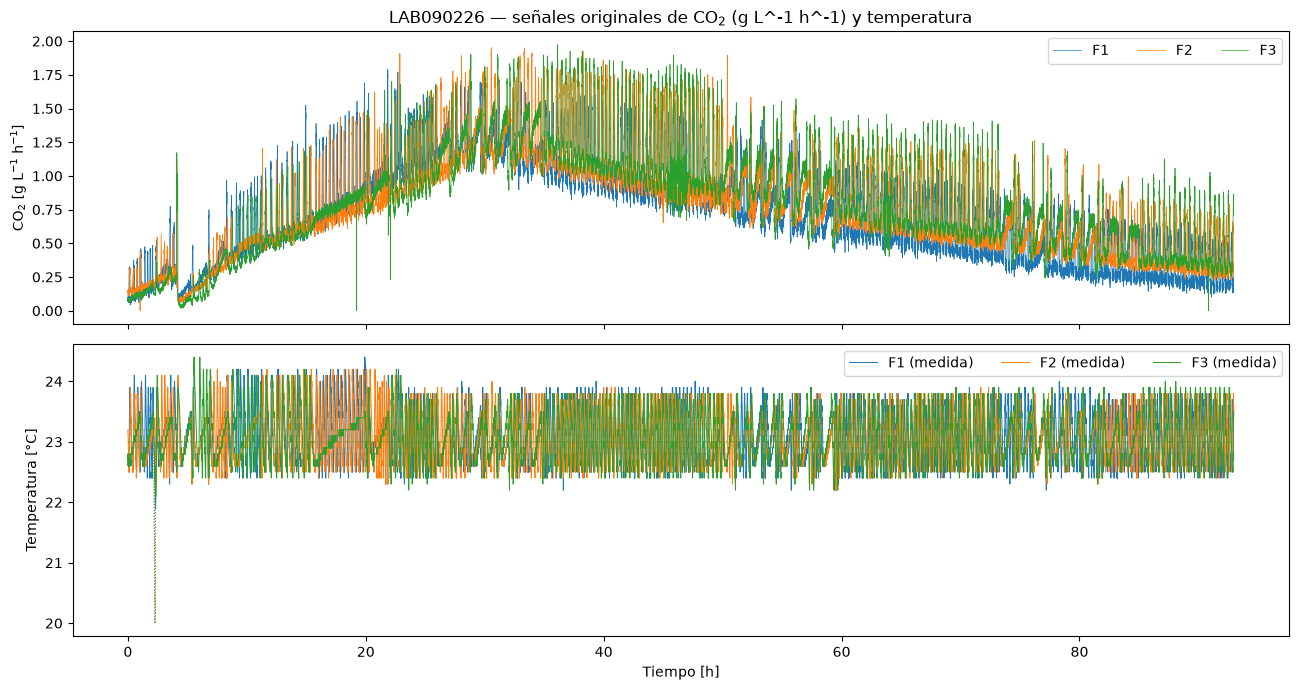

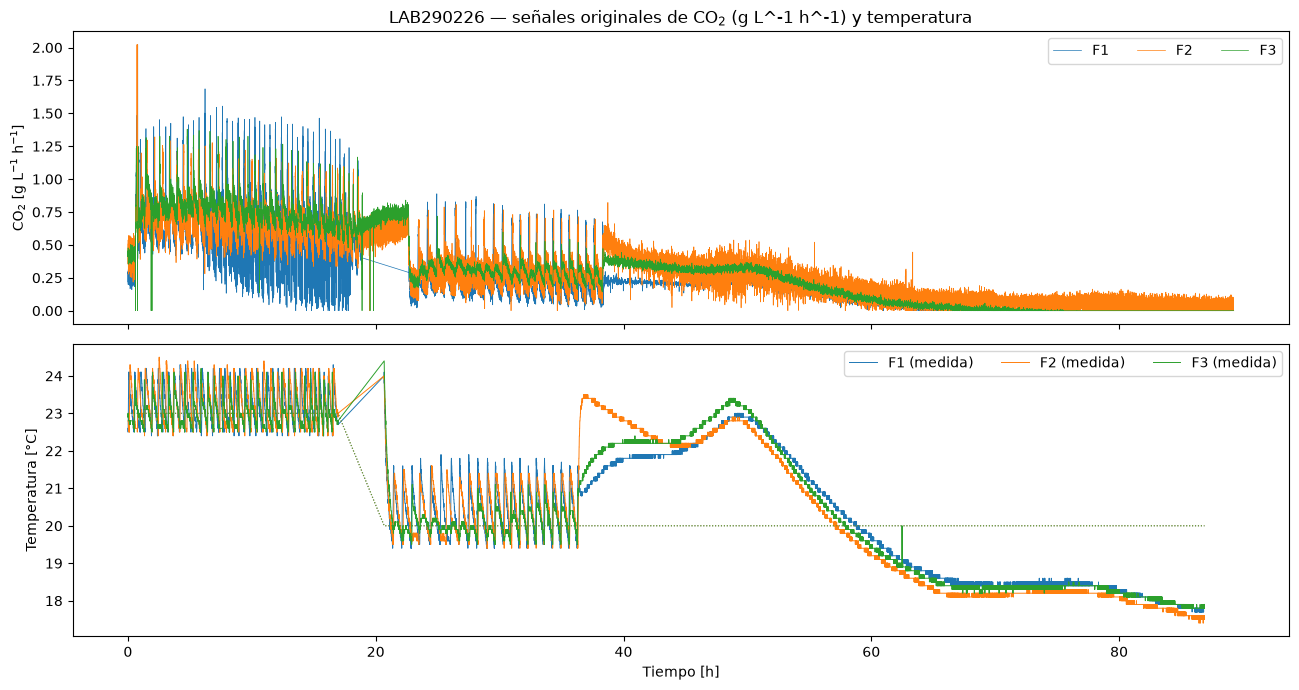

In [3]:
def hours_since_start(ts: pd.Series) -> np.ndarray:
    return (ts - ts.iloc[0]).dt.total_seconds().to_numpy() / 3600.0


# Senales originales: CO2 en g L^-1 h^-1 (conversion post-lectura solo para visualizacion/comparacion con modelo).
# El filtrado posterior se sigue aplicando en SCCM.
for exp, ferms in DATA.items():
    fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
    for ferm, d in ferms.items():
        c, t = d["co2"], d["temp"]
        axes[0].plot(hours_since_start(c["timestamp"]), sccm_to_g_L_h(c["flow_sccm"].to_numpy(dtype=float)), lw=0.5,
                     color=COLORS[ferm], label=ferm)
        axes[1].plot(hours_since_start(t["timestamp"]), t["T"], lw=0.7,
                     color=COLORS[ferm], label=f"{ferm} (medida)")
        axes[1].plot(hours_since_start(t["timestamp"]), t["SP"], lw=0.8, ls=":",
                     color=COLORS[ferm], alpha=0.7)
    axes[0].set_ylabel("CO$_2$ [g L$^{-1}$ h$^{-1}$]")
    axes[0].set_title(f"{exp} — señales originales de CO$_2$ (g L^-1 h^-1) y temperatura")
    axes[0].legend(ncol=3, loc="upper right")
    axes[1].set_ylabel("Temperatura [°C]")
    axes[1].set_xlabel("Tiempo [h]")
    axes[1].legend(ncol=3, loc="upper right")
    fig.tight_layout()
    plt.show()


## 3. Cascada de filtrado offline (réplica exacta de la online)

Las dos clases siguientes replican línea a línea `HampelCausal` y `ButterworthCausalSOS` del GUI online
(`NEW_GUI_filtrado_vCTORREALBA_EZO_USB.py`):

- **Hampel causal**: buffer deslizante de largo $W$ (muestra actual + anteriores). Con menos de 3 muestras la
  señal pasa sin cambios. Mediana y MAD de la ventana; $\sigma_{robusta} = 1.4826\cdot\mathrm{MAD}$;
  $\mathrm{threshold} = \max(k\,\sigma_{robusta}, \Delta_{\min})$; un punto es spike si
  $|x - \mathrm{med}| > \mathrm{threshold}$ y se reemplaza **solo entonces** por la mediana local.
- **Butterworth IIR causal**: `scipy.signal.butter(N, wn, btype="low", output="sos")` con
  $f_s = 1/T_s$, $f_c = 1/(2\pi\tau)$, $\omega_n = f_c/(f_s/2)$; filtrado con `sosfilt` (causal, un solo paso).
  El estado `zi` se inicializa como `sosfilt_zi(sos) * x[0]` (condición de estado estacionario en la primera
  muestra), igual que en el streaming online, evitando el transitorio de arranque.

In [4]:
class HampelCausal:
    '''Replica exacta de HampelCausal del GUI online (causal).'''

    def __init__(self, w, k, min_abs_spike):
        self.w = max(1, int(w))
        self.k = float(k)
        self.min_abs_spike = float(min_abs_spike)
        self.buf = deque(maxlen=self.w)

    def update(self, x):
        x = float(x)
        self.buf.append(x)
        if len(self.buf) < 3:
            return x, False

        arr = np.asarray(self.buf, dtype=float)
        med = float(np.median(arr))
        mad = float(np.median(np.abs(arr - med)))
        sigma = 1.4826 * mad
        threshold = max(self.k * sigma, self.min_abs_spike)
        is_spike = abs(x - med) > threshold
        if is_spike:
            return med, True
        return x, False


class ButterworthCausalSOS:
    '''Replica exacta de ButterworthCausalSOS del GUI online (IIR causal, sin zero-phase).'''

    def __init__(self, dt_seconds, tau_seconds, order):
        self.dt_seconds = float(dt_seconds)
        self.tau_seconds = float(tau_seconds)
        self.order = int(order)
        if self.dt_seconds <= 0:
            raise ValueError("dt_seconds debe ser > 0")
        if self.tau_seconds <= 0:
            raise ValueError("tau_seconds debe ser > 0")
        if self.order < 1:
            raise ValueError("order debe ser >= 1")

        fs = 1.0 / self.dt_seconds
        fc = 1.0 / (2.0 * np.pi * self.tau_seconds)
        wn = fc / (fs / 2.0)
        wn = min(max(wn, 1e-8), 0.999999)

        self.sos = signal.butter(self.order, wn, btype="low", output="sos")
        self.zi = None

    def update(self, x):
        x = float(x)
        x_in = np.asarray([x], dtype=float)
        if self.zi is None:
            self.zi = signal.sosfilt_zi(self.sos) * x
        y, self.zi = signal.sosfilt(self.sos, x_in, zi=self.zi)
        return float(y[-1])


def apply_online_cascade(ts: pd.Series, y: np.ndarray):
    '''Aplica la cascada online (Hampel -> Butterworth) con el Ts real del archivo.'''
    dt_s = np.diff(ts.values).astype("timedelta64[ns]").astype(float) / 1e9
    ts_real = float(np.median(dt_s))
    w = max(1, int(round(W_SPIKE_SECONDS / ts_real)))

    hampel = HampelCausal(w=w, k=K_SPIKE, min_abs_spike=MIN_ABS_SPIKE)
    y_despiked = np.empty_like(y, dtype=float)
    is_spike = np.zeros(len(y), dtype=bool)
    for i, x in enumerate(y):
        y_despiked[i], is_spike[i] = hampel.update(x)

    butter = ButterworthCausalSOS(dt_seconds=ts_real, tau_seconds=TAU_SECONDS, order=BUTTER_ORDER)
    y_filtered = np.empty_like(y_despiked)
    for i, x in enumerate(y_despiked):
        y_filtered[i] = butter.update(x)

    return {"despiked": y_despiked, "filtered": y_filtered, "is_spike": is_spike,
            "ts_real_s": ts_real, "w": w, "dt_max_s": float(dt_s.max())}


RESULTS = {}
for exp, ferms in DATA.items():
    for ferm, d in ferms.items():
        res = apply_online_cascade(d["co2"]["timestamp"], d["co2"]["flow_sccm"].to_numpy(dtype=float))
        RESULTS[(exp, ferm)] = res
        print(f"{exp} {ferm}: Ts={res['ts_real_s']:.3f} s  W={res['w']}  "
              f"spikes={int(res['is_spike'].sum())} ({100 * res['is_spike'].mean():.2f}%)  "
              f"max_gap={res['dt_max_s']:.0f} s")

LAB090226 F1: Ts=10.000 s  W=12  spikes=1425 (4.40%)  max_gap=270 s


LAB090226 F2: Ts=10.000 s  W=12  spikes=1347 (4.16%)  max_gap=270 s


LAB090226 F3: Ts=10.000 s  W=12  spikes=1160 (3.58%)  max_gap=259 s


LAB290226 F1: Ts=10.000 s  W=12  spikes=712 (2.39%)  max_gap=13689 s


LAB290226 F2: Ts=10.000 s  W=12  spikes=795 (2.55%)  max_gap=21 s


LAB290226 F3: Ts=10.000 s  W=12  spikes=500 (1.60%)  max_gap=21 s


## 3bis. Conversion de flujo CO$_{2}$: SCCM $\rightarrow$ g L$^{-1}$ h$^{-1}$ (oficial `NEW_GUI_filtrado_vFINAL.py`)

Se utiliza **exactamente** la conversion activa de la GUI (`flow_sccm_to_co2_g_l_h_plot`), **no** la funcion alternativa `flow_to_rate_g_l_h()` basada en `CO2_DENSITY_G_M3 = 1964.0`.

**Formula:**

$$\mathrm{CO_{2}\,[g\,L^{-1}\,h^{-1}]} = \frac{\mathrm{flow\_sccm} \times \mathrm{CO2\_MOLAR\_MASS} \times 60 \times \mathrm{CO2\_FLOW\_CORRECTION}}{1000 \times \mathrm{STANDARD\_MOLAR\_VOLUME} \times \mathrm{REACTOR\_WORKING\_VOLUME}}$$

**Constantes:**

| Constante | Valor |
|---|---|
| `STANDARD_MOLAR_VOLUME_L_PER_MOL` | 24.16 |
| `CO2_MOLAR_MASS_G_PER_MOL` | 44.0095 |
| `REACTOR_WORKING_VOLUME_L` (volumen de trabajo asumido) | 2.0 L |
| `CO2_FLOW_CORRECTION_FACTOR` (factor de correccion del flujo) | 0.74 |

Con estos valores: `CO2_g_L_h ≈ flow_sccm * 0.04044`.

**Orden del procesado (importante):** el Hampel y el Butterworth se aplican **siempre sobre la senal en SCCM** (sus parametros fueron definidos en SCCM, en particular `delta_min = MIN_ABS_SPIKE = 0.5 SCCM`). Flujo:

```
CO2_raw_SCCM -> Hampel en SCCM -> Butterworth causal en SCCM -> conversion a g/L/h de cada senal
```

No se convierte a g/L/h antes del Hampel. Para cada etapa se generan las 6 senales: `CO2_raw_sccm`, `CO2_hampel_sccm`, `CO2_filtered_sccm` y sus equivalentes `CO2_raw_g_L_h`, `CO2_hampel_g_L_h`, `CO2_filtered_g_L_h`. Las figuras principales usan `CO$_2$ [g L$^{-1}$ h$^{-1}$]` para comparar con el modelo de fermentacion; los diagnosticos conservan SCCM como comprobacion del filtro.


In [5]:
# ---- Verificacion numerica 1 SCCM ~= 0.04044 g L^-1 h^-1 + generacion de senales en ambas unidades ----
# El filtrado (RESULTS) ya se aplico en SCCM; aqui SOLO se convierte despues (no se re-filtra en g/L/h).
FACTOR_G_L_H_PER_SCCM = (CO2_MOLAR_MASS_G_PER_MOL * 60.0 * CO2_FLOW_CORRECTION_FACTOR) / (
    1000.0 * STANDARD_MOLAR_VOLUME_L_PER_MOL * REACTOR_WORKING_VOLUME_L
)
print(f"FACTOR_G_L_H_PER_SCCM = {FACTOR_G_L_H_PER_SCCM:.6f} g L^-1 h^-1 por SCCM")

val_1sccm_scalar = flow_sccm_to_co2_g_l_h_plot(1.0)
val_1sccm_vec = float(sccm_to_g_L_h(np.asarray([1.0]))[0])
print(f"1 SCCM -> escalar={val_1sccm_scalar:.5f} g L^-1 h^-1 | vectorizado={val_1sccm_vec:.5f} g L^-1 h^-1 (esperado ~0.04044)")
assert abs(val_1sccm_scalar - 0.04044) < 5e-5, f"Verificacion fallo: {val_1sccm_scalar}"
assert abs(val_1sccm_vec - 0.04044) < 5e-5, f"Verificacion vectorizada fallo: {val_1sccm_vec}"
assert abs(val_1sccm_scalar - FACTOR_G_L_H_PER_SCCM) < 1e-12
print("Verificacion OK: 1 SCCM ~= 0.04044 g L^-1 h^-1")


def enrich_results_with_g_L_h(data_dict, results_dict):
    """Aplica la conversion post-filtrado y genera las 6 senales por fermentador.

    Requiere que el filtrado ya exista en SCCM en results_dict (despiked/filtered).
    Genera en cada DataFrame co2: CO2_raw_sccm, CO2_hampel_sccm, CO2_filtered_sccm,
    CO2_raw_g_L_h, CO2_hampel_g_L_h, CO2_filtered_g_L_h; y en results_dict:
    raw_sccm/hampel_sccm (=despiked)/filtered_sccm (=filtered) + raw_g_L_h/hampel_g_L_h/filtered_g_L_h.
    """
    for ferm, d in data_dict.items():
        res = results_dict[ferm] if ferm in results_dict else results_dict.get(ferm)
        # Soporta claves (exp, ferm) o ferm segun el diccionario usado
        if res is None:
            continue
        raw_sccm = d["co2"]["flow_sccm"].to_numpy(dtype=float)
        hampel_sccm = np.asarray(res["despiked"], dtype=float)
        filt_sccm = np.asarray(res["filtered"], dtype=float)
        raw_g = sccm_to_g_L_h(raw_sccm)
        hampel_g = sccm_to_g_L_h(hampel_sccm)
        filt_g = sccm_to_g_L_h(filt_sccm)
        # Guardar en results
        res["raw_sccm"] = raw_sccm
        res["hampel_sccm"] = hampel_sccm
        res["filtered_sccm"] = filt_sccm
        res["raw_g_L_h"] = raw_g
        res["hampel_g_L_h"] = hampel_g
        res["filtered_g_L_h"] = filt_g
        # Guardar como columnas trazables
        d["co2"]["CO2_raw_sccm"] = raw_sccm
        d["co2"]["CO2_hampel_sccm"] = hampel_sccm
        d["co2"]["CO2_filtered_sccm"] = filt_sccm
        d["co2"]["CO2_raw_g_L_h"] = raw_g
        d["co2"]["CO2_hampel_g_L_h"] = hampel_g
        d["co2"]["CO2_filtered_g_L_h"] = filt_g


# Aplicar a LAB090226 / LAB290226 (RESULTS usa claves (exp, ferm))
for exp, ferms in DATA.items():
    sub_data = {ferm: ferms[ferm] for ferm in ferms}
    sub_res = {ferm: RESULTS[(exp, ferm)] for ferm in ferms}
    enrich_results_with_g_L_h(sub_data, sub_res)

# Comprobacion rapida de consistencia lineal en un fermentador
exp0, ferm0 = "LAB090226", "F1"
r0 = RESULTS[(exp0, ferm0)]
print(f"Ejemplo {exp0} {ferm0}: raw[0]={r0['raw_sccm'][0]:.3f} SCCM -> {r0['raw_g_L_h'][0]:.5f} g L^-1 h^-1 | "
      f"ratio={r0['raw_g_L_h'][0]/r0['raw_sccm'][0] if r0['raw_sccm'][0] != 0 else float('nan'):.5f}")
print("Columnas CO2 generadas:", [c for c in DATA[exp0][ferm0]['co2'].columns if c.startswith('CO2_')])


FACTOR_G_L_H_PER_SCCM = 0.040439 g L^-1 h^-1 por SCCM
1 SCCM -> escalar=0.04044 g L^-1 h^-1 | vectorizado=0.04044 g L^-1 h^-1 (esperado ~0.04044)
Verificacion OK: 1 SCCM ~= 0.04044 g L^-1 h^-1
Ejemplo LAB090226 F1: raw[0]=2.090 SCCM -> 0.08453 g L^-1 h^-1 | ratio=0.04044
Columnas CO2 generadas: ['CO2_raw_sccm', 'CO2_hampel_sccm', 'CO2_filtered_sccm', 'CO2_raw_g_L_h', 'CO2_hampel_g_L_h', 'CO2_filtered_g_L_h']


## 4. Comparación por fermentador: CO$_2$ bruto → Hampel → Hampel + Butterworth

Los puntos rojos del panel central son las muestras reemplazadas por el Hampel (spikes).

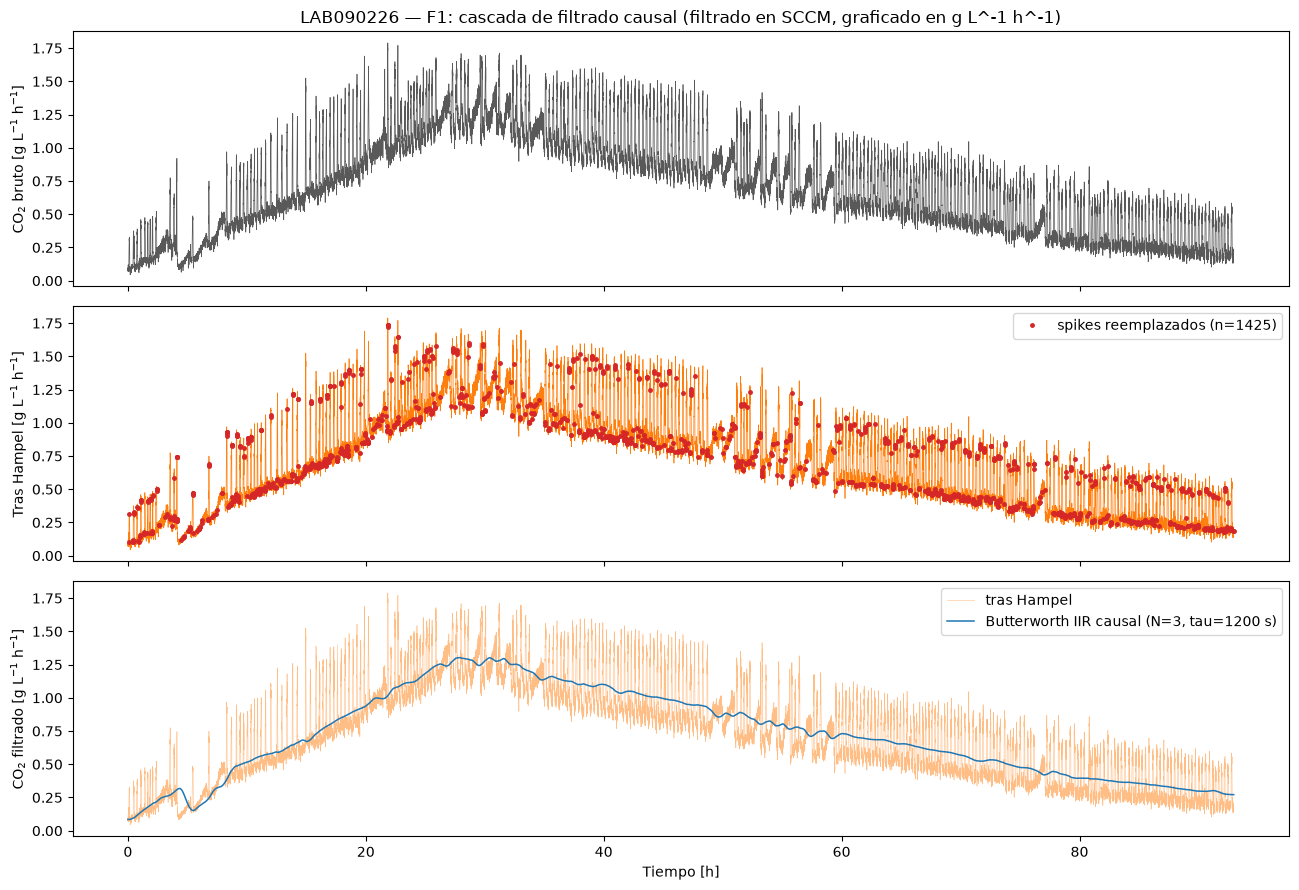

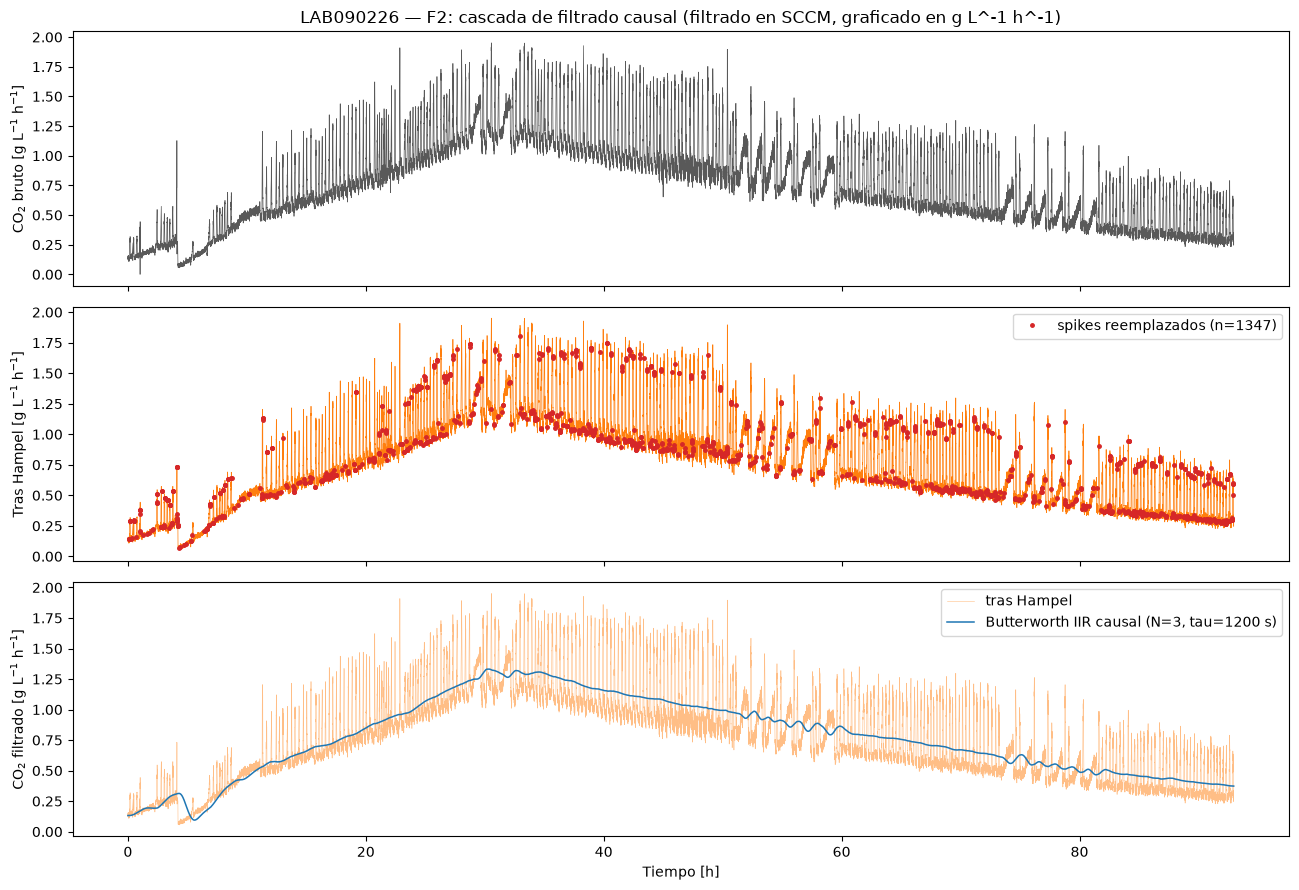

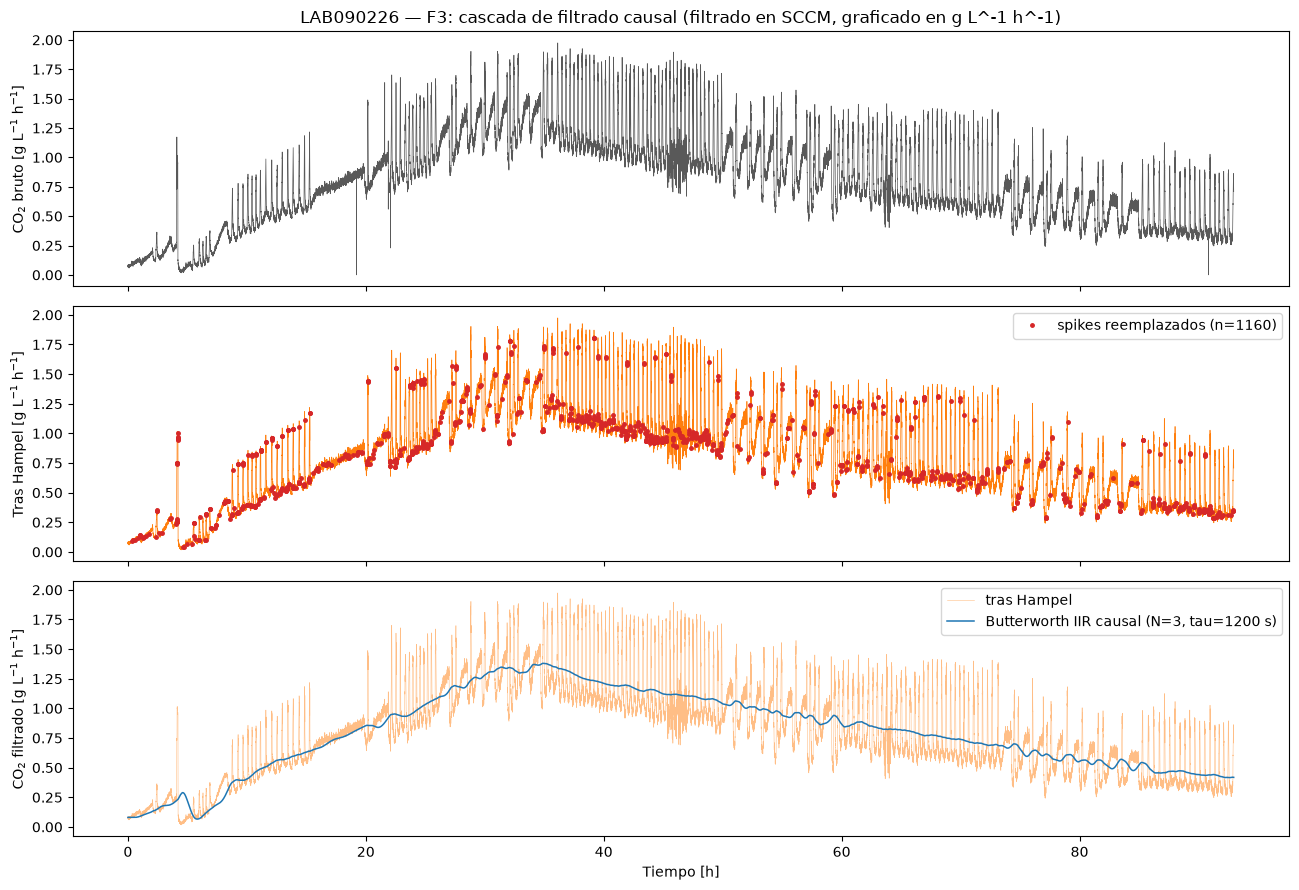

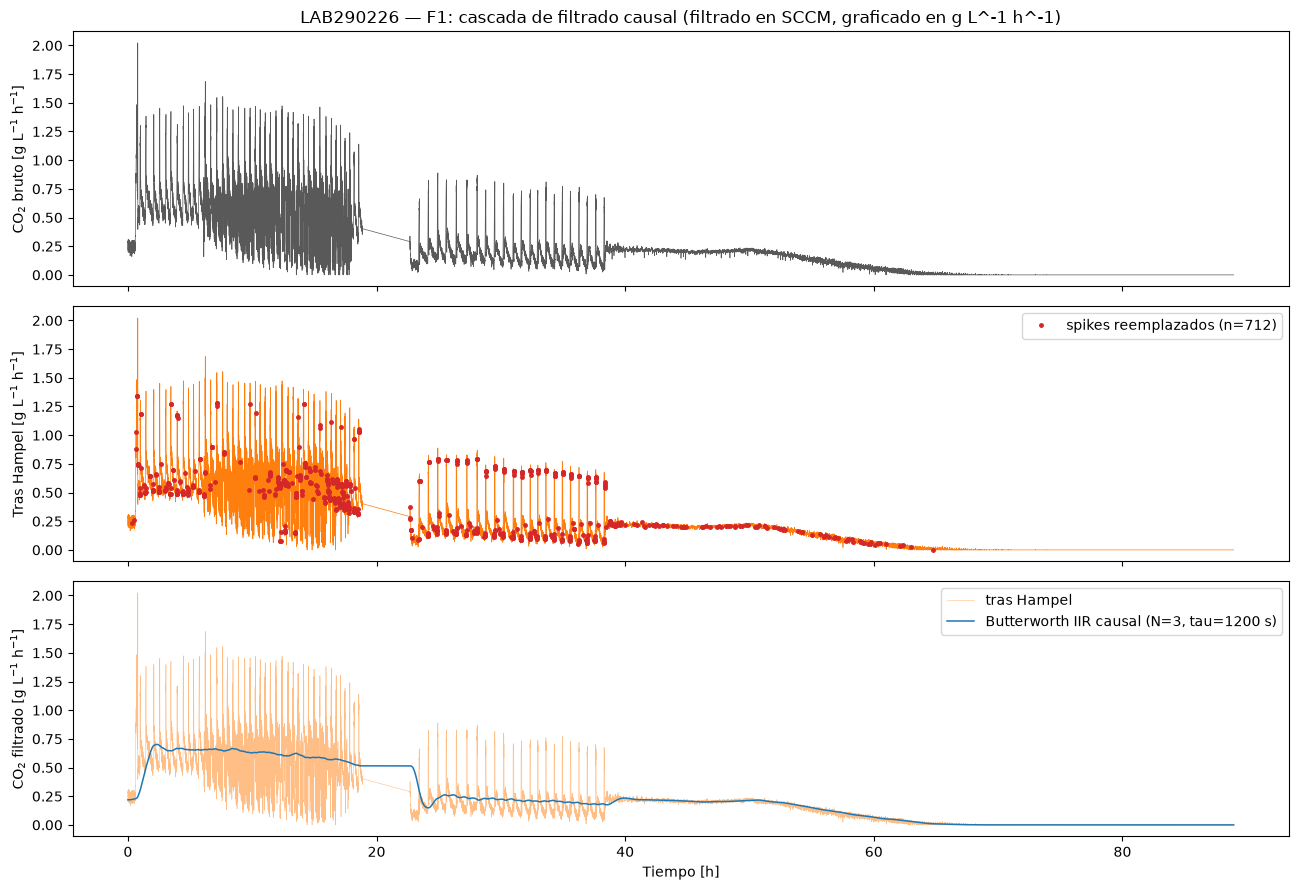

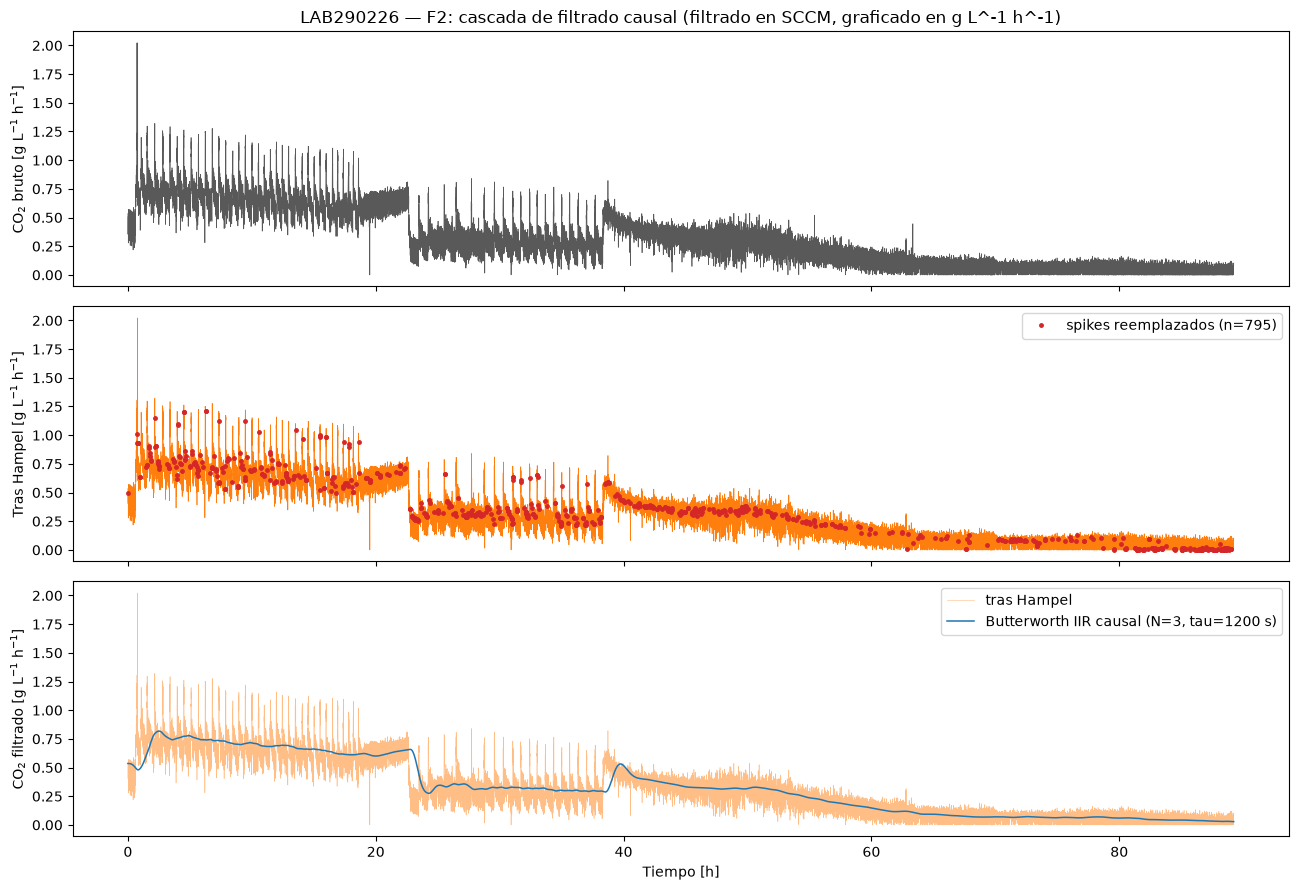

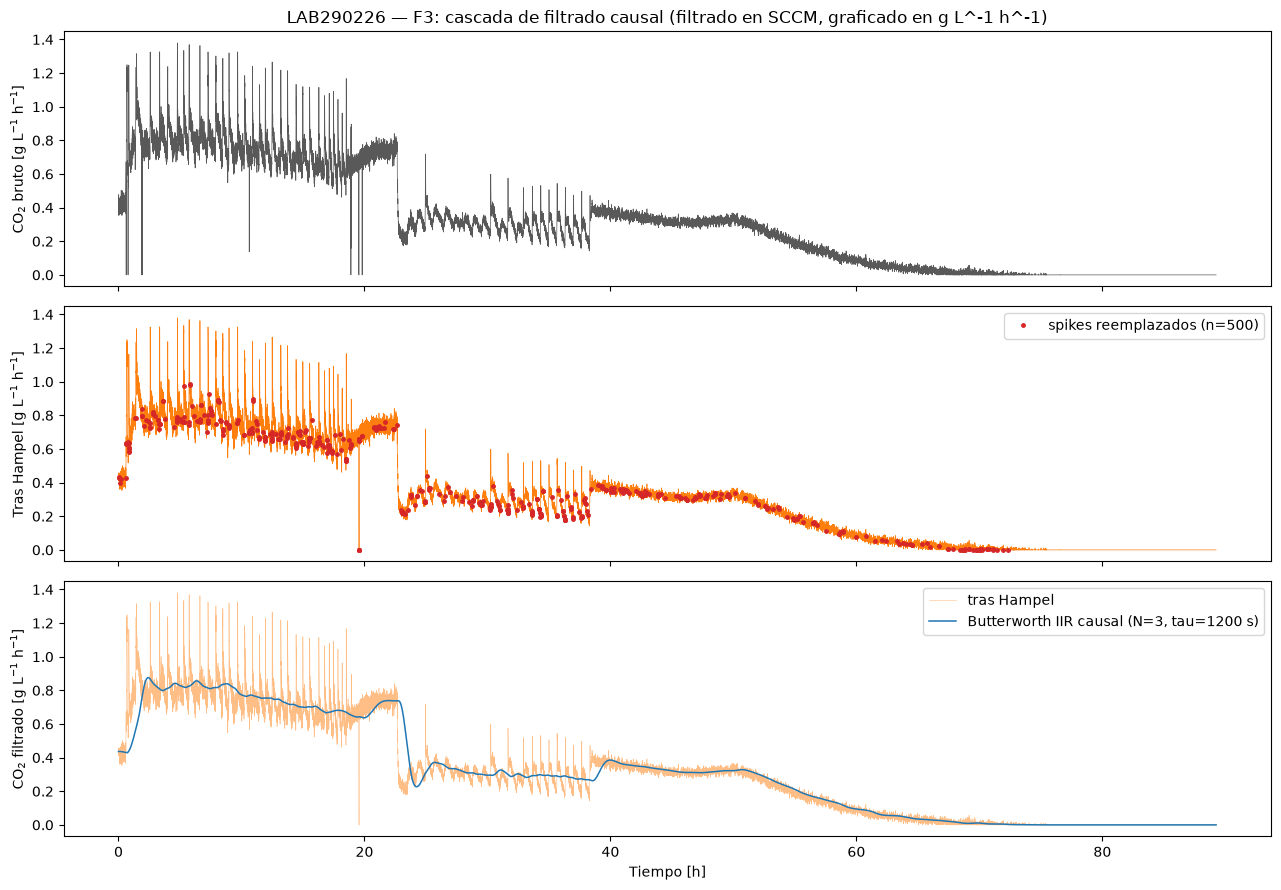

In [6]:
for exp, ferms in DATA.items():
    for ferm, d in ferms.items():
        res = RESULTS[(exp, ferm)]
        # Filtrado ya aplicado en SCCM; conversion solo para graficar en g L^-1 h^-1 (unidad del modelo).
        t_h = hours_since_start(d["co2"]["timestamp"])
        raw_g = res.get("raw_g_L_h", sccm_to_g_L_h(d["co2"]["flow_sccm"].to_numpy(dtype=float)))
        hampel_g = res.get("hampel_g_L_h", sccm_to_g_L_h(res["despiked"]))
        filt_g = res.get("filtered_g_L_h", sccm_to_g_L_h(res["filtered"]))
        fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

        axes[0].plot(t_h, raw_g, lw=0.5, color="0.35")
        axes[0].set_ylabel("CO$_2$ bruto [g L$^{-1}$ h$^{-1}$]")
        axes[0].set_title(f"{exp} — {ferm}: cascada de filtrado causal (filtrado en SCCM, graficado en g L^-1 h^-1)")

        axes[1].plot(t_h, hampel_g, lw=0.5, color="tab:orange")
        spike_idx = np.flatnonzero(res["is_spike"])
        axes[1].plot(t_h[spike_idx], hampel_g[spike_idx], "o", ms=2.5,
                     color="tab:red", label=f"spikes reemplazados (n={len(spike_idx)})")
        axes[1].set_ylabel("Tras Hampel [g L$^{-1}$ h$^{-1}$]")
        axes[1].legend(loc="upper right")

        axes[2].plot(t_h, hampel_g, lw=0.4, color="tab:orange", alpha=0.5, label="tras Hampel")
        axes[2].plot(t_h, filt_g, lw=1.1, color="tab:blue",
                     label=f"Butterworth IIR causal (N={BUTTER_ORDER}, tau={TAU_SECONDS:.0f} s)")
        axes[2].set_ylabel("CO$_2$ filtrado [g L$^{-1}$ h$^{-1}$]")
        axes[2].set_xlabel("Tiempo [h]")
        axes[2].legend(loc="upper right")

        fig.tight_layout()
        plt.show()


## 5. Tabla resumen por señal

Para las señales de temperatura no se aplica filtrado (solo se grafican), por lo que las columnas de Hampel
quedan marcadas con `—`.

In [7]:
summary_rows = []
for exp, ferms in DATA.items():
    for ferm, d in ferms.items():
        res = RESULTS[(exp, ferm)]
        c = d["co2"]
        n_spikes = int(res["is_spike"].sum())
        summary_rows.append({
            "experimento": exp,
            "senal": f"CO2 {ferm}",
            "Ts_med_s": round(res["ts_real_s"], 3),
            "W_hampel": res["w"],
            "n_muestras": len(c),
            "hampel_reemplazos": n_spikes,
            "pct_spikes": round(100.0 * n_spikes / len(c), 3),
            "duracion_h": round((c["timestamp"].iloc[-1] - c["timestamp"].iloc[0]).total_seconds() / 3600.0, 2),
        })
    for ferm, d in ferms.items():
        t = d["temp"]
        summary_rows.append({
            "experimento": exp,
            "senal": f"Temp {ferm}",
            "Ts_med_s": round(median_dt_seconds(t["timestamp"]), 3),
            "W_hampel": "—",
            "n_muestras": len(t),
            "hampel_reemplazos": "—",
            "pct_spikes": "—",
            "duracion_h": round((t["timestamp"].iloc[-1] - t["timestamp"].iloc[0]).total_seconds() / 3600.0, 2),
        })

SUMMARY = pd.DataFrame(summary_rows)
SUMMARY

,experimento,senal,Ts_med_s,W_hampel,n_muestras,hampel_reemplazos,pct_spikes,duracion_h
0,LAB090226,CO2 F1,10.0,12,32357,1425,4.404,92.96
1,LAB090226,CO2 F2,10.0,12,32358,1347,4.163,92.96
2,LAB090226,CO2 F3,10.0,12,32358,1160,3.585,92.96
3,LAB090226,Temp F1,3.0,—,96814,—,—,92.96
4,LAB090226,Temp F2,3.0,—,96814,—,—,92.96
5,LAB090226,Temp F3,3.0,—,96814,—,—,92.96
6,LAB290226,CO2 F1,10.0,12,29833,712,2.387,88.95
7,LAB290226,CO2 F2,10.0,12,31221,795,2.546,89.24
8,LAB290226,CO2 F3,10.0,12,31224,500,1.601,89.25
9,LAB290226,Temp F1,3.0,—,87553,—,—,86.89


## 6. Observaciones automáticas sobre las curvas

In [8]:
print("== Diagnostico de las senales originales ==")
for exp, ferms in DATA.items():
    for ferm, d in ferms.items():
        c, t = d["co2"], d["temp"]
        res = RESULTS[(exp, ferm)]
        counts = c["status"].value_counts().to_dict()
        print(
            f"{exp} {ferm}: flow [{c['flow_sccm'].min():.2f}, {c['flow_sccm'].max():.2f}] SCCM | "
            f"[{sccm_to_g_L_h(np.asarray([c['flow_sccm'].min()]))[0]:.4f}, "
            f"{sccm_to_g_L_h(np.asarray([c['flow_sccm'].max()]))[0]:.4f}] g L^-1 h^-1 | "
            f"status={counts} | max_gap={res['dt_max_s']:.0f} s | "
            f"T[{t['T'].min():.1f}, {t['T'].max():.1f}] C"
        )

print()
print("== Efecto del filtrado (global bruto vs final; SCCM y g L^-1 h^-1) ==")
for exp, ferms in DATA.items():
    for ferm, d in ferms.items():
        res = RESULTS[(exp, ferm)]
        raw = d["co2"]["flow_sccm"].to_numpy(dtype=float)
        print(
            f"{exp} {ferm}: std bruto={np.std(raw):.3f} | std final={np.std(res['filtered']):.3f} SCCM | "
            f"std bruto={np.std(res['raw_g_L_h']):.5f} | std final={np.std(res['filtered_g_L_h']):.5f} g L^-1 h^-1 | "
            f"pico bruto={raw.max():.2f} | pico final={res['filtered'].max():.2f} SCCM"
        )


== Diagnostico de las senales originales ==
LAB090226 F1: flow [1.08, 44.24] SCCM | [0.0437, 1.7891] g L^-1 h^-1 | status={'OK': 32357} | max_gap=270 s | T[21.9, 24.4] C
LAB090226 F2: flow [0.00, 48.24] SCCM | [0.0000, 1.9508] g L^-1 h^-1 | status={'OK': 32358} | max_gap=270 s | T[22.2, 24.2] C
LAB090226 F3: flow [0.00, 48.81] SCCM | [0.0000, 1.9740] g L^-1 h^-1 | status={'OK': 32356, 'Bajo rango': 2} | max_gap=259 s | T[22.1, 24.4] C
LAB290226 F1: flow [0.00, 50.00] SCCM | [0.0000, 2.0220] g L^-1 h^-1 | status={'OK': 24439, 'Bajo rango': 5390, 'Alto rango': 4} | max_gap=13689 s | T[17.7, 24.3] C
LAB290226 F2: flow [0.00, 50.00] SCCM | [0.0000, 2.0220] g L^-1 h^-1 | status={'OK': 30750, 'Bajo rango': 464, 'Alto rango': 7} | max_gap=21 s | T[17.4, 24.5] C
LAB290226 F3: flow [0.00, 34.11] SCCM | [0.0000, 1.3792] g L^-1 h^-1 | status={'OK': 27055, 'Bajo rango': 4169} | max_gap=21 s | T[17.8, 24.4] C

== Efecto del filtrado (global bruto vs final; SCCM y g L^-1 h^-1) ==
LAB090226 F1: std b

## 7. Datos de respaldo: `LAB090226/last_backups`

La carpeta se renombro de `last_backuos` a `last_backups`. Contiene backups **globales** con los tres
fermentadores intercalados en un solo archivo:

| Archivo | Contenido | Ventana | Uso en esta seccion |
|---|---|---|---|
| `backup_global_co2.csv` | CO$_2$ F1/F2/F3 (`timestamp, fermentador, flow_sccm, current_ma, voltage, status`) | 2026-02-04 17:23 -> 2026-02-11 10:51 | si |
| `backup_global_temperatura.csv` | Temperatura F1/F2/F3 | 2026-02-04 17:02 -> 2026-02-11 10:51 (misma ventana que el CO$_2$) | si |
| `backup_global.csv` | Solo temperatura, ventana 2026-01-29 -> 2026-02-03 (prueba LAB290226) | 2026-01-29 10:02 -> 2026-02-03 09:57 | no |

`backup_global.csv` no se incluye en el analisis: corresponde a la ventana de la prueba LAB290226 y no tiene
contraparte de CO$_2$ dentro de `last_backups`, por lo que no forma un par CO$_2$/temperatura coherente.

Se aplica exactamente el mismo proceso que en las secciones anteriores: division por `fermentador`, $T_s$ real
por senal (mediana de incrementos), misma cascada Hampel causal -> Butterworth IIR causal con los mismos
parametros (sin re-optimizar).

In [9]:
BKP_DIR = DATA_DIR / "LAB090226" / "last_backups"

co2_all = load_co2(BKP_DIR / "backup_global_co2.csv")
temp_all = load_temp(BKP_DIR / "backup_global_temperatura.csv")

DATA_BKP = {}
for ferm in ("F1", "F2", "F3"):
    DATA_BKP[ferm] = {
        "co2": co2_all[co2_all["fermentador"] == ferm].reset_index(drop=True),
        "temp": temp_all[temp_all["fermentador"] == ferm].reset_index(drop=True),
    }

rows = []
for ferm, d in DATA_BKP.items():
    c, t = d["co2"], d["temp"]
    rows.append({
        "fermentador": ferm,
        "n_CO2": len(c),
        "Ts_CO2_med_s": round(median_dt_seconds(c["timestamp"]), 3),
        "n_Temp": len(t),
        "Ts_Temp_med_s": round(median_dt_seconds(t["timestamp"]), 3),
        "inicio_CO2": str(c["timestamp"].iloc[0]),
        "fin_CO2": str(c["timestamp"].iloc[-1]),
        "dur_h": round((c["timestamp"].iloc[-1] - c["timestamp"].iloc[0]).total_seconds() / 3600.0, 2),
    })
pd.DataFrame(rows)

,fermentador,n_CO2,Ts_CO2_med_s,n_Temp,Ts_Temp_med_s,inicio_CO2,fin_CO2,dur_h
0,F1,46565,10.0,138490,3.0,2026-02-04 17:23:14,2026-02-11 10:51:02,161.46
1,F2,46566,10.0,138490,3.0,2026-02-04 17:23:14,2026-02-11 10:51:02,161.46
2,F3,46565,10.0,138489,3.0,2026-02-04 17:23:14,2026-02-11 10:51:02,161.46


### 7.1 Señales originales de los backups

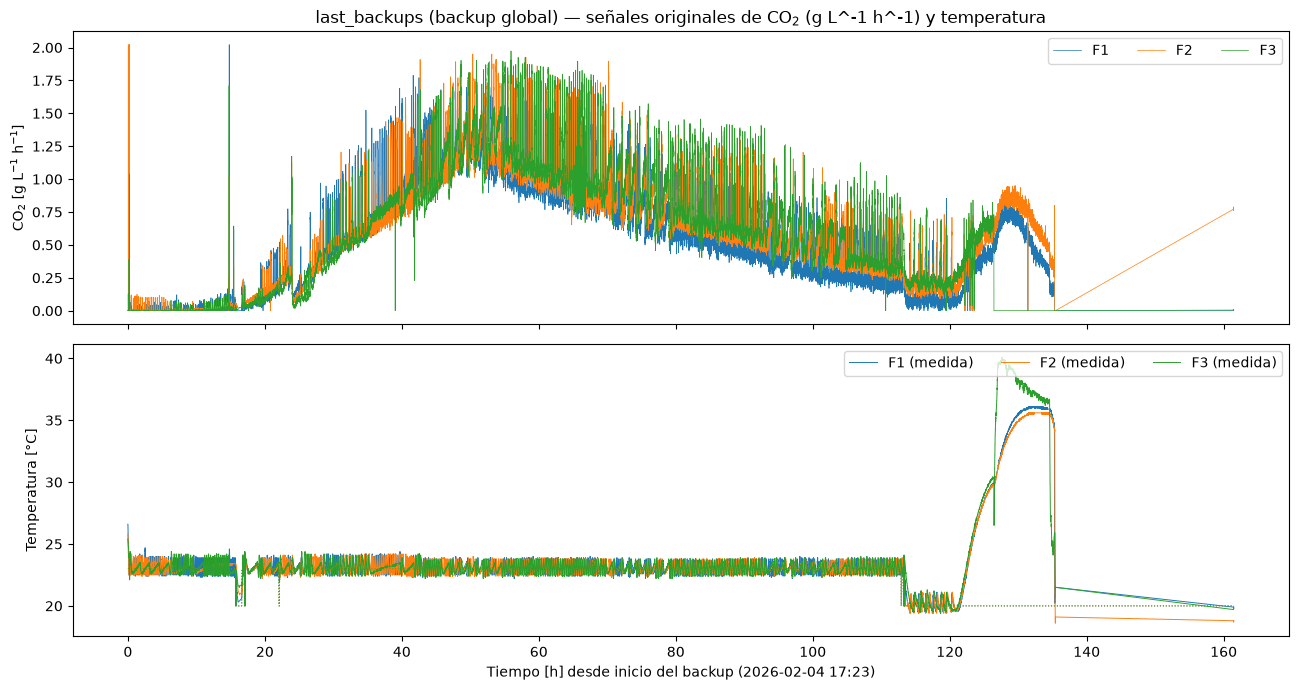

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
for ferm, d in DATA_BKP.items():
    c, t = d["co2"], d["temp"]
    axes[0].plot(hours_since_start(c["timestamp"]), sccm_to_g_L_h(c["flow_sccm"].to_numpy(dtype=float)), lw=0.5,
                 color=COLORS[ferm], label=ferm)
    axes[1].plot(hours_since_start(t["timestamp"]), t["T"], lw=0.7,
                 color=COLORS[ferm], label=f"{ferm} (medida)")
    axes[1].plot(hours_since_start(t["timestamp"]), t["SP"], lw=0.8, ls=":",
                 color=COLORS[ferm], alpha=0.7)
axes[0].set_ylabel("CO$_2$ [g L$^{-1}$ h$^{-1}$]")
axes[0].set_title("last_backups (backup global) — señales originales de CO$_2$ (g L^-1 h^-1) y temperatura")
axes[0].legend(ncol=3, loc="upper right")
axes[1].set_ylabel("Temperatura [°C]")
axes[1].set_xlabel("Tiempo [h] desde inicio del backup (2026-02-04 17:23)")
axes[1].legend(ncol=3, loc="upper right")
fig.tight_layout()
plt.show()


### 7.2 Cascada de filtrado y comparación por fermentador

Misma cascada y mismos parámetros. Ojo: los backups contienen un corte de varias horas (~26 h) entre
2026-02-05 y 2026-02-06; el filtro online procesa la serie como un único flujo, tal como ocurrió en
operación. Los puntos rojos del panel central son los spikes reemplazados por el Hampel.

backup F1: Ts=10.000 s  W=12  spikes=2032 (4.36%)  max_gap=93622 s


backup F2: Ts=10.000 s  W=12  spikes=1762 (3.78%)  max_gap=93622 s


backup F3: Ts=10.000 s  W=12  spikes=1404 (3.02%)  max_gap=93622 s
Columnas CO2 backup generadas: ['CO2_raw_sccm', 'CO2_hampel_sccm', 'CO2_filtered_sccm', 'CO2_raw_g_L_h', 'CO2_hampel_g_L_h', 'CO2_filtered_g_L_h']


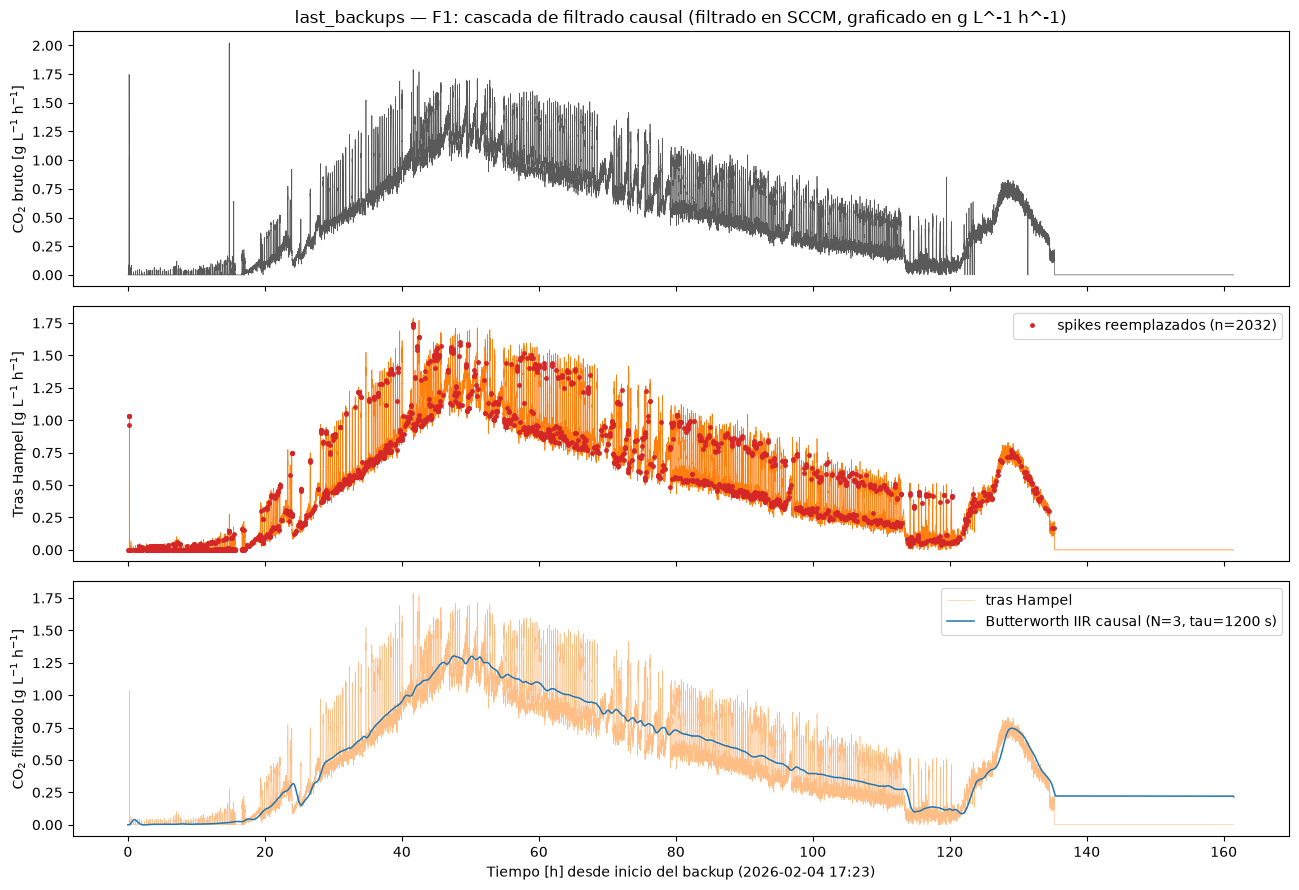

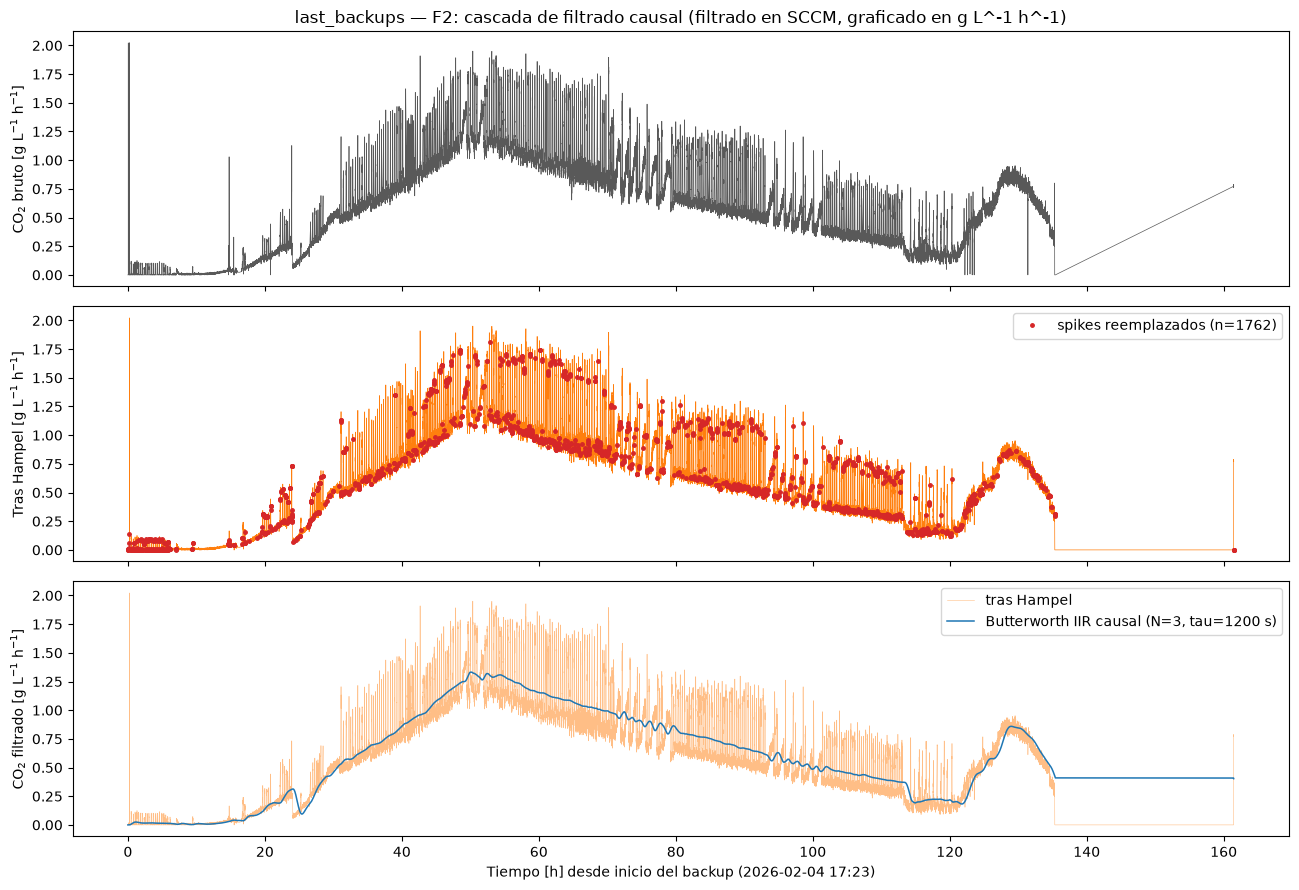

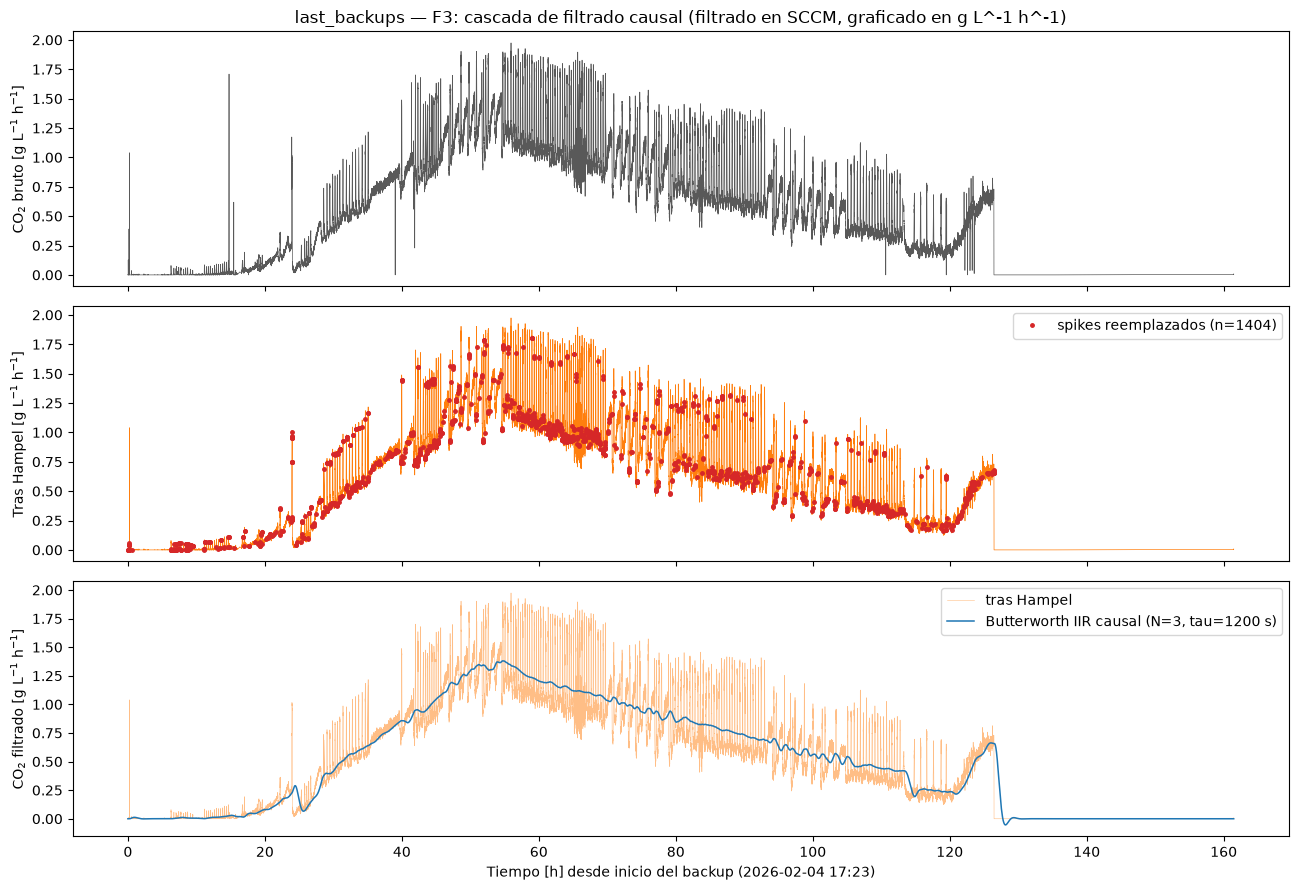

In [11]:
RESULTS_BKP = {}
for ferm, d in DATA_BKP.items():
    res = apply_online_cascade(d["co2"]["timestamp"], d["co2"]["flow_sccm"].to_numpy(dtype=float))
    RESULTS_BKP[ferm] = res
    print(f"backup {ferm}: Ts={res['ts_real_s']:.3f} s  W={res['w']}  "
          f"spikes={int(res['is_spike'].sum())} ({100 * res['is_spike'].mean():.2f}%)  "
          f"max_gap={res['dt_max_s']:.0f} s")

# Conversion post-filtrado (filtrado ya hecho en SCCM) -> genera las 6 senales tambien para backups
enrich_results_with_g_L_h(DATA_BKP, RESULTS_BKP)
print("Columnas CO2 backup generadas:", [c for c in DATA_BKP['F1']['co2'].columns if c.startswith('CO2_')])

for ferm, d in DATA_BKP.items():
    res = RESULTS_BKP[ferm]
    t_h = hours_since_start(d["co2"]["timestamp"])
    raw_g = res["raw_g_L_h"]
    hampel_g = res["hampel_g_L_h"]
    filt_g = res["filtered_g_L_h"]
    fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

    axes[0].plot(t_h, raw_g, lw=0.5, color="0.35")
    axes[0].set_ylabel("CO$_2$ bruto [g L$^{-1}$ h$^{-1}$]")
    axes[0].set_title(f"last_backups — {ferm}: cascada de filtrado causal (filtrado en SCCM, graficado en g L^-1 h^-1)")

    axes[1].plot(t_h, hampel_g, lw=0.5, color="tab:orange")
    spike_idx = np.flatnonzero(res["is_spike"])
    axes[1].plot(t_h[spike_idx], hampel_g[spike_idx], "o", ms=2.5,
                 color="tab:red", label=f"spikes reemplazados (n={len(spike_idx)})")
    axes[1].set_ylabel("Tras Hampel [g L$^{-1}$ h$^{-1}$]")
    axes[1].legend(loc="upper right")

    axes[2].plot(t_h, hampel_g, lw=0.4, color="tab:orange", alpha=0.5, label="tras Hampel")
    axes[2].plot(t_h, filt_g, lw=1.1, color="tab:blue",
                 label=f"Butterworth IIR causal (N={BUTTER_ORDER}, tau={TAU_SECONDS:.0f} s)")
    axes[2].set_ylabel("CO$_2$ filtrado [g L$^{-1}$ h$^{-1}$]")
    axes[2].set_xlabel("Tiempo [h] desde inicio del backup (2026-02-04 17:23)")
    axes[2].legend(loc="upper right")

    fig.tight_layout()
    plt.show()


### 7.3 Tabla resumen (backups) y observaciones

In [12]:
summary_rows = []
for ferm, d in DATA_BKP.items():
    res = RESULTS_BKP[ferm]
    c = d["co2"]
    n_spikes = int(res["is_spike"].sum())
    summary_rows.append({
        "experimento": "last_backups",
        "senal": f"CO2 {ferm}",
        "Ts_med_s": round(res["ts_real_s"], 3),
        "W_hampel": res["w"],
        "n_muestras": len(c),
        "hampel_reemplazos": n_spikes,
        "pct_spikes": round(100.0 * n_spikes / len(c), 3),
        "duracion_h": round((c["timestamp"].iloc[-1] - c["timestamp"].iloc[0]).total_seconds() / 3600.0, 2),
    })
for ferm, d in DATA_BKP.items():
    t = d["temp"]
    summary_rows.append({
        "experimento": "last_backups",
        "senal": f"Temp {ferm}",
        "Ts_med_s": round(median_dt_seconds(t["timestamp"]), 3),
        "W_hampel": "—",
        "n_muestras": len(t),
        "hampel_reemplazos": "—",
        "pct_spikes": "—",
        "duracion_h": round((t["timestamp"].iloc[-1] - t["timestamp"].iloc[0]).total_seconds() / 3600.0, 2),
    })

BKP_SUMMARY = pd.DataFrame(summary_rows)
display(BKP_SUMMARY)

print("== Diagnostico de los backups (SCCM y g L^-1 h^-1) ==")
for ferm, d in DATA_BKP.items():
    c, t = d["co2"], d["temp"]
    res = RESULTS_BKP[ferm]
    raw = c["flow_sccm"].to_numpy(dtype=float)
    print(
        f"backup {ferm}: flow [{raw.min():.2f}, {raw.max():.2f}] SCCM | "
        f"[{res['raw_g_L_h'].min():.4f}, {res['raw_g_L_h'].max():.4f}] g L^-1 h^-1 | "
        f"status={c['status'].value_counts().to_dict()} | max_gap={res['dt_max_s']:.0f} s | "
        f"std bruto={np.std(raw):.3f} -> std final={np.std(res['filtered']):.3f} SCCM | "
        f"std bruto={np.std(res['raw_g_L_h']):.5f} -> std final={np.std(res['filtered_g_L_h']):.5f} g L^-1 h^-1 | "
        f"pico bruto={raw.max():.2f} -> pico final={res['filtered'].max():.2f} SCCM | "
        f"T[{t['T'].min():.1f}, {t['T'].max():.1f}] C"
    )


,experimento,senal,Ts_med_s,W_hampel,n_muestras,hampel_reemplazos,pct_spikes,duracion_h
0,last_backups,CO2 F1,10.0,12,46565,2032,4.364,161.46
1,last_backups,CO2 F2,10.0,12,46566,1762,3.784,161.46
2,last_backups,CO2 F3,10.0,12,46565,1404,3.015,161.46
3,last_backups,Temp F1,3.0,—,138490,—,—,161.47
4,last_backups,Temp F2,3.0,—,138490,—,—,161.47
5,last_backups,Temp F3,3.0,—,138489,—,—,161.47


== Diagnostico de los backups (SCCM y g L^-1 h^-1) ==
backup F1: flow [0.00, 50.00] SCCM | [0.0000, 2.0220] g L^-1 h^-1 | status={'OK': 42581, 'Bajo rango': 3983, 'Alto rango': 1} | max_gap=93622 s | std bruto=10.116 -> std final=9.539 SCCM | std bruto=0.40907 -> std final=0.38575 g L^-1 h^-1 | pico bruto=50.00 -> pico final=32.21 SCCM | T[19.4, 36.1] C
backup F2: flow [0.00, 50.00] SCCM | [0.0000, 2.0220] g L^-1 h^-1 | status={'OK': 46010, 'Bajo rango': 552, 'Alto rango': 4} | max_gap=93622 s | std bruto=10.252 -> std final=9.556 SCCM | std bruto=0.41457 -> std final=0.38645 g L^-1 h^-1 | pico bruto=50.00 -> pico final=32.92 SCCM | T[18.6, 35.6] C
backup F3: flow [0.00, 48.81] SCCM | [0.0000, 1.9740] g L^-1 h^-1 | status={'OK': 43484, 'Bajo rango': 3081} | max_gap=93622 s | std bruto=11.415 -> std final=10.621 SCCM | std bruto=0.46160 -> std final=0.42952 g L^-1 h^-1 | pico bruto=48.81 -> pico final=34.13 SCCM | T[19.4, 40.1] C
